In [ ]:
# Checando as versões

import pandas as pd
import numpy as np

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Pandas: 3.0.3
NumPy: 2.4.6


In [ ]:
# 120 anos de Olimpíadas

## Objetivo

Analisar evolução da participação e a conquista do espaço feminino entre 1896 e 2016 utilizando dados históricos dos Jogos Olímpicos.

#Montagem

Abaixo, alguns testes e a importação da Database. Certos ajustes e testes foram elaborados antes do polimento final.

In [2]:
from pathlib import Path

for arquivo in Path("../data").iterdir():
    print(arquivo.name)

noc_region.csv
dataset_olympics.csv


In [3]:
import pandas as pd

df = pd.read_csv("../data/dataset_olympics.csv")

In [4]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [5]:
df.shape

(70000, 15)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      70000 non-null  int64  
 1   Name    70000 non-null  str    
 2   Sex     70000 non-null  str    
 3   Age     67268 non-null  float64
 4   Height  53746 non-null  float64
 5   Weight  52899 non-null  float64
 6   Team    70000 non-null  str    
 7   NOC     70000 non-null  str    
 8   Games   70000 non-null  str    
 9   Year    70000 non-null  int64  
 10  Season  70000 non-null  str    
 11  City    70000 non-null  str    
 12  Sport   70000 non-null  str    
 13  Event   70000 non-null  str    
 14  Medal   9690 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 8.0 MB


In [7]:
df.columns.tolist()

['ID',
 'Name',
 'Sex',
 'Age',
 'Height',
 'Weight',
 'Team',
 'NOC',
 'Games',
 'Year',
 'Season',
 'City',
 'Sport',
 'Event',
 'Medal']

In [8]:
df["Sex"].value_counts()

Sex
M    51877
F    18123
Name: count, dtype: int64

In [11]:
participacao = (
    df.groupby(["Year", "Sex"])
      .size()
      .unstack(fill_value=0)
)

participacao.head()

Sex,F,M
Year,,
1896,0,65
1900,13,618
1904,2,306
1906,2,429
1908,12,853


In [12]:
participacao["Total"] = participacao["F"] + participacao["M"]

participacao["Pct_Feminina"] = (
    participacao["F"] /
    participacao["Total"]
) * 100

participacao.head()

Sex,F,M,Total,Pct_Feminina
Year,,,,
1896,0,65,65,0.000000
1900,13,618,631,2.060222
1904,2,306,308,0.649351
1906,2,429,431,0.464037
1908,12,853,865,1.387283


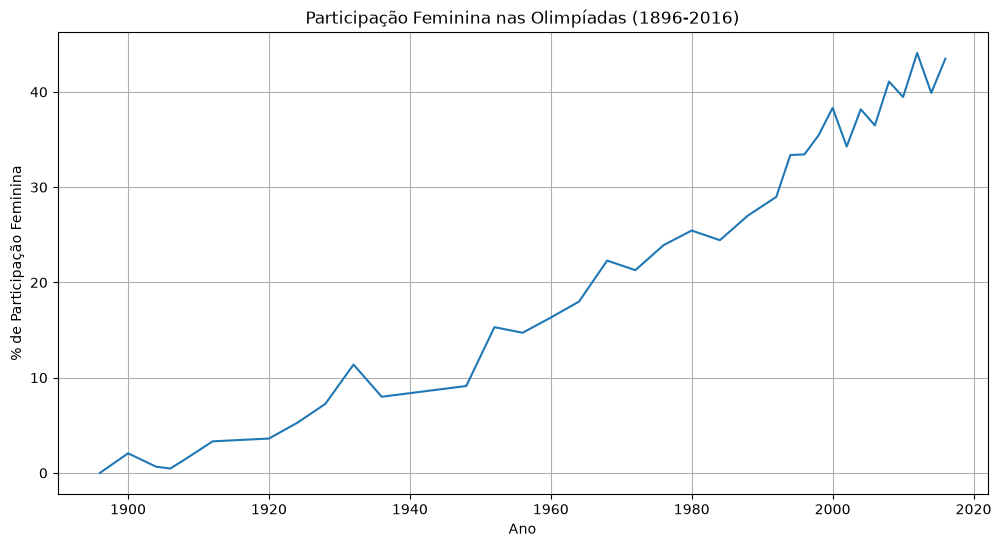

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    participacao.index,
    participacao["Pct_Feminina"]
)

plt.title("Participação Feminina nas Olimpíadas (1896-2016)")
plt.xlabel("Ano")
plt.ylabel("% de Participação Feminina")

plt.grid(True)

plt.show()

In [20]:
comparacao = participacao.loc[[1896, 2016]].copy()

comparacao["Pct_M"] = (
    comparacao["M"] /
    comparacao["Total"]
) * 100

comparacao["Pct_F"] = (
    comparacao["F"] /
    comparacao["Total"]
) * 100

comparacao[["Pct_M", "Pct_F"]]

Sex,Pct_M,Pct_F
Year,,
1896,100.000000,0.000000
2016,56.517007,43.482993


Abaixo, o Gráfico polido

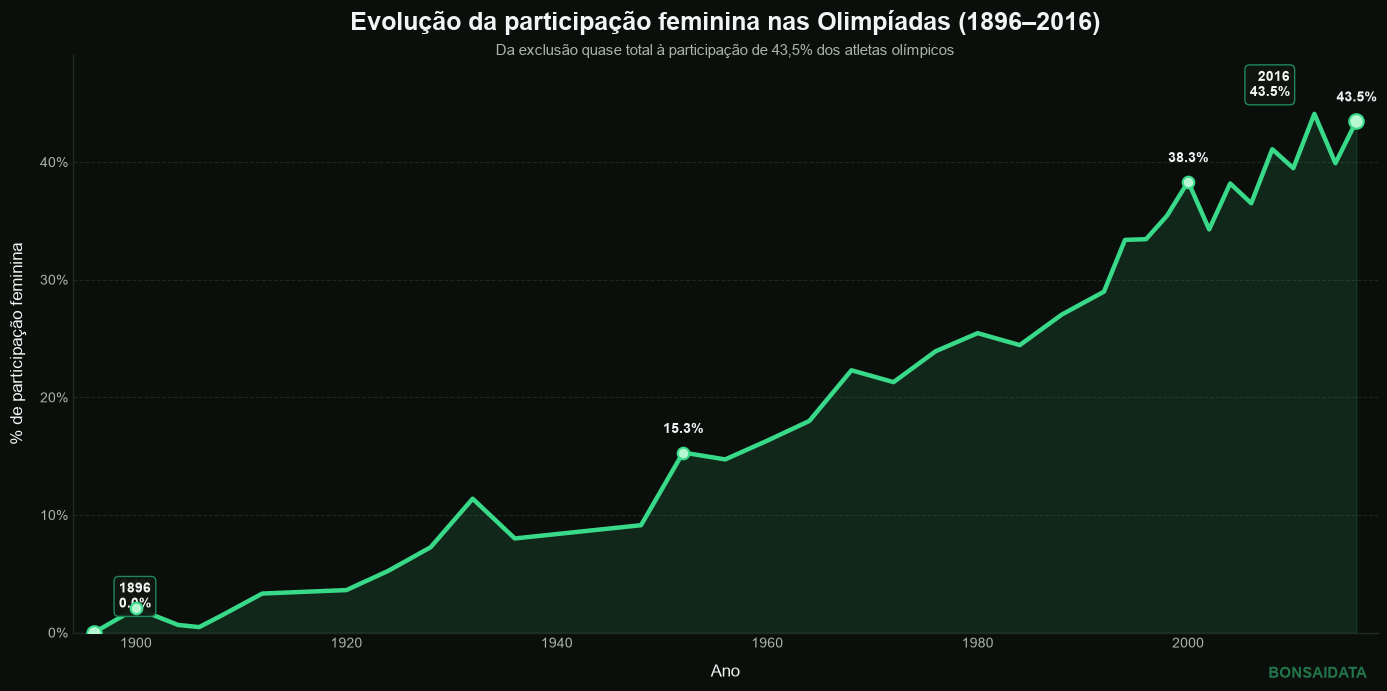

In [35]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# A 'participacao' DEVE existir com:
# index = Year
# coluna = 'Pct_Feminina'

dados = participacao.copy().sort_index()
anos = dados.index
pct = dados["Pct_Feminina"]

ano_ini = anos.min()
ano_fim = anos.max()

pct_ini = dados.loc[ano_ini, "Pct_Feminina"]
pct_fim = dados.loc[ano_fim, "Pct_Feminina"]
ganho = pct_fim - pct_ini

# Cores
fundo = "#0b0f0b"
verde = "#39d98a"
verde_escuro = "#1f8f5f"
verde_claro = "#b8f5d1"
texto = "#f2f5f3"
subtexto = "#aab3ad"
grade = "#1e2a23"

fig, ax = plt.subplots(figsize=(14, 7), facecolor=fundo)
ax.set_facecolor(fundo)

# Área + linha
ax.fill_between(
    anos,
    pct,
    color=verde,
    alpha=0.12
)

ax.plot(
    anos,
    pct,
    color=verde,
    linewidth=3.2
)

# Pontos-chave
pontos = [1900, 1952, 2000, 2016]
pontos = [p for p in pontos if p in dados.index]

for ano in pontos:
    valor = dados.loc[ano, "Pct_Feminina"]
    ax.scatter(ano, valor, s=70, color=verde_claro, edgecolor=verde, linewidth=1.5, zorder=5)

    ax.annotate(
        f"{valor:.1f}%",
        xy=(ano, valor),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom",
        color=texto,
        fontsize=10,
        fontweight="bold"
    )

# Destaque do início e fim
ax.scatter([ano_ini, ano_fim], [pct_ini, pct_fim], s=110, color=verde_claro, edgecolor=verde, linewidth=1.5, zorder=6)

ax.annotate(
    f"{ano_ini}\n{pct_ini:.1f}%",
    xy=(ano_ini, pct_ini),
    xytext=(18, 18),
    textcoords="offset points",
    color=texto,
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#111611", edgecolor=verde_escuro, alpha=0.95)
)

ax.annotate(
    f"{ano_fim}\n{pct_fim:.1f}%",
    xy=(ano_fim, pct_fim),
    xytext=(-48, 18),
    textcoords="offset points",
    ha="right",
    color=texto,
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#111611", edgecolor=verde_escuro, alpha=0.95)
)

# Título do graf. e subtítulo
ax.set_title(
    "Evolução da participação feminina nas Olimpíadas (1896–2016)",
    color=texto,
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    1.00,
    "Da exclusão quase total à participação de 43,5% dos atletas olímpicos",
    transform=ax.transAxes,
    ha="center",
    color=subtexto,
    fontsize=11
)

# Eixos
ax.set_xlabel("Ano", color=texto, fontsize=12, labelpad=10)
ax.set_ylabel("% de participação feminina", color=texto, fontsize=12, labelpad=10)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.0f}%"))

# Grade e moldura
ax.grid(True, axis="y", color=grade, linestyle="--", linewidth=0.8, alpha=0.9)
ax.grid(False, axis="x")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(grade)
ax.spines["bottom"].set_color(grade)

ax.tick_params(colors=subtexto)

ax.set_xlim(ano_ini - 2, ano_fim + 2)
ax.set_ylim(0, max(45, pct.max() + 5))

plt.tight_layout()

fig.text(
    0.98,
    0.02,
    "BONSAIDATA",
    ha="right",
    va="bottom",
    fontsize=11,
    color="#39d98a",
    fontweight="bold",
    alpha=0.5
)

plt.show()

## Principais marcos

- 1896 > Mulheres praticamente ausentes das Olimpíadas (0,0%)
- 1952 > Participação feminina ultrapassa 15% dos atletas (15,3%)
- 2016 > Mulheres representam quase metade dos participantes (43,5%)

### Leitura do gráfico

Esta análise investiga a evolução da participação feminina nos Jogos Olímpicos entre 1896 e 2016, utilizando dados históricos de atletas e eventos.

O espaço das mulheres em 1896 neste âmbito, era praticamente inexistente. Em 2016, já representava uma parcela enorme dos atletas. O avanço não foi rápido nem linear, entretanto fora um avanço,  iniciando tímido, ganhando força no meio do século XX e acelerando bastante nas décadas finais.

Por fim, o gráfico mostra mais do que números. Ele mostra o quanto o espaço das mulheres nas Olimpíadas foi sendo conquistado ao longo de mais de 100 anos. De uma porcentagem de 0% em 1896, para 15,3% em 1952, até 43.5% de participação em 2016.

Esta base de dados postada pelo "Bhanupratap Biswas" na Kaggle foi essencial para evidenciar a história, que embora chocante, demonstre também de maneira positiva, o quanto a luta pelo espaço valeu à pena e cada vez mais, o mundo do esporte está mais democrático.

## Principais conclusões

- A participação feminina saiu de 0% para 43,5% entre 1896 e 2016.
- O crescimento foi gradual durante a primeira metade do século XX.
- A aceleração mais significativa ocorreu após a década de 1950.
- Em 2016 as mulheres já representavam quase metade dos atletas olímpicos.

## Fonte

Dataset obtido através do Kaggle:
- Olympic Data
- Autor: Bhanupratap Biswas

# Autor

Gabriel Araujo - Bonsai Data

https://github.com/BonsaiData

## Próximos estudos

- Participação feminina por modalidade esportiva
- Evolução das medalhas femininas ao longo do tempo
- Comparação entre Jogos Olímpicos de Verão e Inverno